# DocMind — RAG Evaluation (Google Colab)

Faithfully reproduces the DocMind backend RAG pipeline to answer the whole `question_bank.xlsx` automatically, **with the reranker off and on**, and writes the answers (+ retrieved sources) back to a new spreadsheet.

**Before running:**
1. Set the runtime to a **GPU** (Runtime → Change runtime type → T4 GPU). The 9.6 GB `gemma4:e4b` + 2.5 GB `qwen3-embedding:4b` are slow on CPU.
2. Upload the whole **`Evaluation/`** directory to `/content/Evaluation` (so that `/content/Evaluation/question_bank.xlsx` and `/content/Evaluation/subjects/` exist).

**Mirrors `backend/src/.env`:** `gemma4:e4b`, `qwen3-embedding:4b`, `EMBEDDING_SIZE=2000`, retrieval `limit=5` / `threshold=0.3`, rerank `BAAI/bge-reranker-base` overfetch ×3, generation `temperature=0.2`.

**Runtime note:** the run is dominated by ~2 generations per question (≈400 total) and can take a while. Embeddings and answers are cached to `Evaluation/_eval_cache/`, so if Colab disconnects just re-run the cells — it resumes where it left off.

**Tip:** for a fast dry run, set `ONLY_SUBJECTS = ["hci"]` in the config cell first.

In [1]:
# --------------------------------------------------------------------------- #
# Step 1: Upload Evaluation.zip (skip this cell if you've already uploaded it)
# --------------------------------------------------------------------------- #
from google.colab import files
uploaded = files.upload()   # a file picker will pop up — select Evaluation.zip

Saving Evaluation.zip to Evaluation.zip


In [2]:
# --------------------------------------------------------------------------- #
# Step 2: Unzip it to /content/Evaluation
# --------------------------------------------------------------------------- #
import zipfile, os
from pathlib import Path

zip_path = "Evaluation.zip"   # adjust if your file has a different name
extract_to = "/content"       # zip will create /content/Evaluation if it's structured right

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Sanity check
print(os.listdir("/content/Evaluation"))

['question_bank.xlsx', 'question_bank_evaluated.xlsx', '_eval_cache', 'subjects']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 · Install dependencies + Ollama, start the server, pull the models

In [2]:
# Install Python dependencies into the Colab kernel.
# (pandas / openpyxl are usually preinstalled, but listed here for safety.)
!pip install -q openai qdrant-client sentence-transformers pymupdf python-pptx openpyxl pandas

^C


In [4]:
# Install Ollama (same trick as backend/run_ollama_server_colab_trick.ipynb).
!sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (1,954 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently

In [ ]:
import subprocess, os, time, requests

# Restart any running server so a changed OLLAMA_CONTEXT_LENGTH takes effect.
os.system("pkill -f 'ollama serve'")
time.sleep(3)

# OLLAMA_CONTEXT_LENGTH raises the context window above the 4096 default. Long
# RAG prompts (5 chunks; some are big atomic tables, ~8k tokens) otherwise fill
# the entire 4096-token window and leave just 1 token to generate -> 'The' stubs
# (finish_reason='length'). 16384 fits the largest observed prompts with plenty
# of room to answer; raise to 32768 if generation still warns finish_reason=length.
proc = subprocess.Popen(
    ["ollama", "serve"],
    env={**os.environ, "OLLAMA_HOST": "0.0.0.0:11434", "OLLAMA_ORIGINS": "*",
         "OLLAMA_CONTEXT_LENGTH": "16384"},
    stdout=subprocess.PIPE, stderr=subprocess.PIPE,
)
for i in range(30):
    try:
        requests.get("http://localhost:11434")
        print("✅ Ollama is up (OLLAMA_CONTEXT_LENGTH=16384)!")
        break
    except Exception:
        print(f"⏳ Waiting for Ollama... ({i+1})")
        time.sleep(2)
else:
    print(proc.stderr.read().decode())
    raise RuntimeError("❌ Ollama failed to start")

In [6]:
# Pull the exact models the DocMind backend uses (see backend/src/.env).
!ollama pull gemma4:e4b
!ollama pull qwen3-embedding:4b
!ollama list



NAME                  ID              SIZE      MODIFIED               
qwen3-embedding:4b    df5bd2e3c74c    2.5 GB    Less than a second ago    
gemma4:e4b            c6eb396dbd59    9.6 GB    24 seconds ago            


## 2 · Config
Point `BASE_DIR` at the uploaded `Evaluation/` folder; all knobs mirror `backend/src/.env`.

In [2]:
import os, json, pickle, re, time
from pathlib import Path
from string import Template
from openai import OpenAI

# --------------------------------------------------------------------------- #
# Paths — point these at the uploaded Evaluation/ directory.
# --------------------------------------------------------------------------- #
def _find_base_dir() -> Path:
    for cand in ["/content/Evaluation", "Evaluation", "."]:
        p = Path(cand)
        if (p / "question_bank.xlsx").exists() and (p / "subjects").is_dir():
            return p.resolve()
    raise FileNotFoundError(
        "Could not locate Evaluation/ (need question_bank.xlsx + subjects/). "
        "Upload the Evaluation directory to /content/Evaluation."
    )

BASE_DIR     = _find_base_dir()
SUBJECTS_DIR = BASE_DIR / "subjects"
XLSX_IN      = BASE_DIR / "question_bank.xlsx"
XLSX_OUT     = BASE_DIR / "question_bank_evaluated.xlsx"
CACHE_DIR    = BASE_DIR / "_eval_cache"
QDRANT_PATH  = str(BASE_DIR / "_qdrant_db")
CACHE_DIR.mkdir(exist_ok=True)
print("BASE_DIR:", BASE_DIR)

# --------------------------------------------------------------------------- #
# Models / params — mirror backend/src/.env exactly.
# --------------------------------------------------------------------------- #
GEN_MODEL_ID     = "gemma4:e4b"
EMB_MODEL_ID     = "qwen3-embedding:4b"
EMBEDDING_SIZE   = 2000        # requested dimensions (auto-detected if Ollama ignores it)
LIMIT            = 5           # AGENT_RETRIEVAL_LIMIT / tutor-chat answer limit
THRESHOLD        = 0.3         # AGENT_RETRIEVAL_THRESHOLD / tutor-chat threshold
RERANK_OVERFETCH = 3           # RERANK_OVERFETCH
RERANK_MODEL_ID  = "BAAI/bge-reranker-base"
TEMPERATURE      = 0.2         # DEFAULT_GENERATION_TEMPERATURE
MAX_TOKENS       = 64000       # DEFAULT_GENERATION_MAX_TOKENS
MAX_INPUT_CHARS  = 128000      # DEFAULT_INPUT_MAX_CHARACTERS (process_text truncation)
EMB_BATCH        = 16          # embedding batch size (speed only; vectors are identical)

# Set to a list like ["hci"] for a quick single-subject dry run; None = all subjects.
ONLY_SUBJECTS = None

# OpenAI-compatible client pointing at the local Ollama server.
client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")

def _strip_surrogates(text: str) -> str:
    # Drop lone/unpaired surrogate codepoints some PDFs emit (e.g. \udfc1).
    # They can't be UTF-8 encoded and crash the OpenAI / Qdrant JSON serializers;
    # valid non-ASCII (e.g. Arabic) is preserved.
    return (text or "").encode("utf-8", "ignore").decode("utf-8", "ignore")

def process_text(text: str) -> str:
    # Mirrors OpenAIProvider.process_text: strip + truncate to MAX_INPUT_CHARS.
    return _strip_surrogates(text).strip()[:MAX_INPUT_CHARS]

print("Config ready.")

BASE_DIR: D:\College\DOCMIND\Evaluation\Evaluation
Config ready.


## 3 · Smoke test (confirm chat + embeddings, capture the real embedding dim)

In [ ]:
# Smoke test: confirm chat + embeddings respond, and capture the REAL embedding dim.
chat = client.chat.completions.create(
    model=GEN_MODEL_ID,
    messages=[{"role": "user", "content": "Reply with the single word: OK"}],
    temperature=0.0, max_tokens=2000,
)
_m = chat.choices[0].message
print("chat:", (_m.content or getattr(_m, "reasoning", ""))[:200])

# Mirror production: request dimensions=EMBEDDING_SIZE. If Ollama rejects the
# param we fall back and size everything to whatever the model actually returns.
try:
    emb = client.embeddings.create(model=EMB_MODEL_ID, input=["hello world"], dimensions=EMBEDDING_SIZE)
    USE_DIMENSIONS = True
except Exception as e:
    print("'dimensions' param rejected, retrying without it:", e)
    emb = client.embeddings.create(model=EMB_MODEL_ID, input=["hello world"])
    USE_DIMENSIONS = False
EMB_DIM = len(emb.data[0].embedding)
print(f"embedding dim = {EMB_DIM} (requested {EMBEDDING_SIZE}, dimensions_supported={USE_DIMENSIONS})")

chat: OK
embedding dim = 2000 (requested 2000, dimensions_supported=True)


## 4 · Ingestion / chunking (verbatim port of the backend `ingestion_service`)

In [ ]:
# =============================================================================
# Ingestion / chunking — copied VERBATIM from
# backend/src/services/ingestion_service.py so chunking is byte-identical to
# production. Pure functions (only fitz / pptx / stdlib); no backend deps.
# =============================================================================
import logging
from dataclasses import dataclass
from typing import List, Optional, Tuple

logger = logging.getLogger("docmind.ingestion")

DEFAULT_CHUNK_SIZE = 1000
DEFAULT_OVERLAP = 150


@dataclass
class IngestedChunk:
    text: str
    metadata: dict


# --------------------------------------------------------------------------- #
# Text cleaning + structure-aware splitting
# --------------------------------------------------------------------------- #
def _clean(text: str) -> str:
    text = re.sub(r"^\s*\d+\s*$", "", text, flags=re.MULTILINE)  # bare page nums
    text = re.sub(r"-\n(\w)", r"\1", text)                       # de-hyphenate
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


_PARA_RE = re.compile(r"\n\s*\n")
_SENT_RE = re.compile(r"(?<=[.!?])\s+")


def _atomize(text: str, max_size: int) -> List[str]:
    atoms: List[str] = []
    for para in _PARA_RE.split(text):
        para = para.strip()
        if not para:
            continue
        if len(para) <= max_size:
            atoms.append(para)
            continue
        for line in para.split("\n"):
            line = line.strip()
            if not line:
                continue
            if len(line) <= max_size:
                atoms.append(line)
                continue
            for sent in _SENT_RE.split(line):
                sent = sent.strip()
                if not sent:
                    continue
                if len(sent) <= max_size:
                    atoms.append(sent)
                else:  # pathological single token — hard slice as last resort
                    for i in range(0, len(sent), max_size):
                        atoms.append(sent[i:i + max_size])
    return atoms


def _merge_with_overlap(atoms: List[str], chunk_size: int, overlap: int) -> List[str]:
    chunks: List[str] = []
    cur: List[str] = []
    cur_len = 0
    for atom in atoms:
        add = len(atom) + (1 if cur else 0)
        if cur and cur_len + add > chunk_size:
            chunks.append(" ".join(cur))
            tail: List[str] = []
            tail_len = 0
            for a in reversed(cur):
                if tail_len + len(a) + 1 > overlap:
                    break
                tail.insert(0, a)
                tail_len += len(a) + 1
            cur = tail
            cur_len = sum(len(a) + 1 for a in cur)
        cur.append(atom)
        cur_len += add
    if cur:
        chunks.append(" ".join(cur))
    return chunks


def _split(text: str, chunk_size: int = DEFAULT_CHUNK_SIZE,
           overlap: int = DEFAULT_OVERLAP) -> List[str]:
    if not text or not text.strip():
        return []
    return _merge_with_overlap(_atomize(text, chunk_size), chunk_size, overlap)


def _with_breadcrumb(text: str, heading: Optional[str]) -> str:
    if heading and not text.lstrip().startswith(f"[{heading}]"):
        return f"[{heading}]\n{text}"
    return text


# --------------------------------------------------------------------------- #
# PDF: native table extraction + font-size heading detection
# --------------------------------------------------------------------------- #
def _intersects(a, b) -> bool:
    return not (a[2] <= b[0] or b[2] <= a[0] or a[3] <= b[1] or b[3] <= a[1])


def _intersects_any(bbox, boxes) -> bool:
    return bbox is not None and any(_intersects(bbox, b) for b in boxes)


def _rows_to_md(rows: List[list]) -> str:
    def cell(c) -> str:
        return ("" if c is None else str(c)).strip().replace("\n", " ").replace("|", "\\|")

    if not rows:
        return ""
    ncols = max(len(r) for r in rows)
    out = ["| " + " | ".join(cell(c) for c in (rows[0] + [""] * (ncols - len(rows[0])))) + " |"]
    out.append("| " + " | ".join(["---"] * ncols) + " |")
    for r in rows[1:]:
        out.append("| " + " | ".join(cell(c) for c in (r + [""] * (ncols - len(r)))) + " |")
    return "\n".join(out)


def _extract_tables(page) -> Tuple[list, List[str]]:
    boxes: list = []
    mds: List[str] = []
    try:
        finder = page.find_tables()
    except Exception:
        return boxes, mds
    for t in getattr(finder, "tables", []):
        try:
            data = t.extract()
        except Exception:
            continue
        nrows = len(data)
        ncols = max((len(r) for r in data), default=0)
        if nrows < 2 or ncols < 2:  # skip false positives (single col/row)
            continue
        try:
            md = (t.to_markdown() or "").strip()
        except Exception:
            md = _rows_to_md(data)
        if md:
            mds.append(md)
            boxes.append(tuple(t.bbox))
    return boxes, mds


def _join_lines(lines: List[str]) -> str:
    out = ""
    for ln in lines:
        if not out:
            out = ln
        elif out.endswith("-") and len(out) >= 2 and out[-2].isalpha():
            out = out[:-1] + ln
        else:
            out += " " + ln
    return out.strip()


def _prose_blocks(page, table_boxes) -> Tuple[List[List[Tuple[str, float]]], float]:
    try:
        data = page.get_text("dict")
    except Exception:
        return [], 0.0
    size_chars: dict = {}
    blocks: List[List[Tuple[str, float]]] = []
    for block in data.get("blocks", []):
        if block.get("type") != 0:  # 0 == text block; skip images
            continue
        if _intersects_any(block.get("bbox"), table_boxes):
            continue
        lines: List[Tuple[str, float]] = []
        for line in block.get("lines", []):
            spans = line.get("spans", [])
            txt = "".join(s.get("text", "") for s in spans).strip()
            if not txt:
                continue
            line_size = 0.0
            for s in spans:
                sz = round(float(s.get("size", 0.0)), 1)
                line_size = max(line_size, sz)
                stripped = s.get("text", "").strip()
                if stripped:
                    size_chars[sz] = size_chars.get(sz, 0) + len(stripped)
            lines.append((txt, line_size))
        if lines:
            blocks.append(lines)
    body_size = max(size_chars, key=size_chars.get) if size_chars else 0.0
    return blocks, body_size


def _looks_like_heading(text: str, size: float, body_size: float) -> bool:
    return bool(
        body_size
        and text
        and len(text) <= 120
        and size >= body_size * 1.18
        and not text.endswith((".", "!", "?", ",", ";"))
    )


def _segments_from_blocks(blocks, body_size, heading):
    segments: List[Tuple[str, Optional[str]]] = []
    for lines in blocks:
        para: List[str] = []
        for txt, size in lines:
            if _looks_like_heading(txt, size, body_size):
                if para:
                    segments.append((_join_lines(para), heading))
                    para = []
                heading = txt
            else:
                para.append(txt)
        if para:
            segments.append((_join_lines(para), heading))
    return segments, heading


def _group_segments(segments):
    groups: List[dict] = []
    for text, heading in segments:
        if groups and groups[-1]["heading"] == heading:
            groups[-1]["paras"].append(text)
        else:
            groups.append({"heading": heading, "paras": [text]})
    return [{"heading": g["heading"], "text": "\n\n".join(g["paras"])} for g in groups]


def ingest_pdf(path) -> List[IngestedChunk]:
    import fitz  # PyMuPDF

    chunks: List[IngestedChunk] = []
    heading: Optional[str] = None  # carried across pages
    with fitz.open(str(path)) as doc:
        for page_idx, page in enumerate(doc):
            page_no = page_idx + 1
            part = 0

            table_boxes, table_mds = _extract_tables(page)
            for md in table_mds:
                chunks.append(
                    IngestedChunk(
                        text=_with_breadcrumb(md, heading),
                        metadata={
                            "source": path.name,
                            "page": page_no,
                            "part": part,
                            "kind": "table",
                            "section": heading,
                        },
                    )
                )
                part += 1

            blocks_info, body_size = _prose_blocks(page, table_boxes)
            segments, heading = _segments_from_blocks(blocks_info, body_size, heading)
            for grp in _group_segments(segments):
                cleaned = _clean(grp["text"])
                for piece in _split(cleaned):
                    chunks.append(
                        IngestedChunk(
                            text=_with_breadcrumb(piece, grp["heading"]),
                            metadata={
                                "source": path.name,
                                "page": page_no,
                                "part": part,
                                "kind": "text",
                                "section": grp["heading"],
                            },
                        )
                    )
                    part += 1
    return chunks


# --------------------------------------------------------------------------- #
# PPTX: table-aware, slide title as heading
# --------------------------------------------------------------------------- #
def _pptx_table_to_md(table) -> str:
    rows: List[list] = []
    for row in table.rows:
        rows.append([cell.text for cell in row.cells])
    return _rows_to_md(rows)


def _slide_title(slide) -> Optional[str]:
    try:
        title = slide.shapes.title
        if title is not None and title.text and title.text.strip():
            return title.text.strip()
    except Exception:
        pass
    return None


def ingest_pptx(path) -> List[IngestedChunk]:
    from pptx import Presentation

    chunks: List[IngestedChunk] = []
    prs = Presentation(str(path))
    for slide_idx, slide in enumerate(prs.slides):
        slide_no = slide_idx + 1
        part = 0
        title = _slide_title(slide)
        try:
            title_shape = slide.shapes.title
        except Exception:
            title_shape = None

        buffer: List[str] = []
        for shape in slide.shapes:
            if shape is title_shape:
                continue  # title becomes the breadcrumb, not body text
            if getattr(shape, "has_table", False):
                md = _pptx_table_to_md(shape.table)
                if md:
                    chunks.append(
                        IngestedChunk(
                            text=_with_breadcrumb(md, title),
                            metadata={
                                "source": path.name,
                                "slide": slide_no,
                                "part": part,
                                "kind": "table",
                                "section": title,
                            },
                        )
                    )
                    part += 1
            elif getattr(shape, "has_text_frame", False) and shape.text and shape.text.strip():
                buffer.append(shape.text.strip())

        cleaned = _clean("\n\n".join(buffer))
        for piece in _split(cleaned):
            chunks.append(
                IngestedChunk(
                    text=_with_breadcrumb(piece, title),
                    metadata={
                        "source": path.name,
                        "slide": slide_no,
                        "part": part,
                        "kind": "text",
                        "section": title,
                    },
                )
            )
            part += 1
    return chunks


def ingest_file(path) -> List[IngestedChunk]:
    """Dispatch based on extension (matches backend ingest_file)."""
    ext = path.suffix.lower()
    if ext == ".pdf":
        return ingest_pdf(path)
    if ext == ".pptx":
        return ingest_pptx(path)
    if ext in {".txt", ".md"}:
        text = path.read_text(encoding="utf-8", errors="replace")
        return [
            IngestedChunk(text=piece, metadata={"source": path.name, "part": i, "kind": "text"})
            for i, piece in enumerate(_split(_clean(text)))
        ]
    logger.warning("Unsupported extension %s for %s", ext, path)
    return []

## 5 · Phase A — build the per-subject vector index
Embeds each subject's materials once (cached) into a `tutor_<subject>` Qdrant collection.

In [8]:
# =============================================================================
# Phase A.1 — embed every subject's materials and build a per-subject Qdrant
# collection (`tutor_<subject>`), mirroring RAGService.index_chunks +
# collection_for_subject. Embeddings are cached per subject so a disconnect
# resumes without re-embedding.
# =============================================================================
import pandas as pd
from qdrant_client import QdrantClient, models

# Open a single local (file-backed) Qdrant client. Guard against re-running the
# cell in the same kernel (local mode forbids two clients on one path).
try:
    qdrant.close()
except Exception:
    pass
qdrant = QdrantClient(path=QDRANT_PATH)


def _slug(name: str) -> str:
    return re.sub(r"[^a-z0-9_]+", "_", name.lower()).strip("_")


def collection_for_subject(subject: str) -> str:
    return f"tutor_{_slug(subject)}"


def embed_texts(texts):
    """Batched embeddings, mirroring OpenAIProvider.embed_text (dimensions=EMBEDDING_SIZE)."""
    out = []
    inputs = [process_text(t) for t in texts]
    for i in range(0, len(inputs), EMB_BATCH):
        batch = inputs[i:i + EMB_BATCH]
        kwargs = {"model": EMB_MODEL_ID, "input": batch}
        if USE_DIMENSIONS:
            kwargs["dimensions"] = EMBEDDING_SIZE
        resp = client.embeddings.create(**kwargs)
        out.extend([d.embedding for d in resp.data])
    return out


SUBJECT_COLLECTION = {}
SUBJECT_MANIFEST = {}

subject_folders = sorted([p for p in SUBJECTS_DIR.iterdir() if p.is_dir()])
if ONLY_SUBJECTS:
    subject_folders = [p for p in subject_folders if p.name in ONLY_SUBJECTS]

for folder in subject_folders:
    subject = folder.name
    coll = collection_for_subject(subject)
    cache_f = CACHE_DIR / f"emb_{_slug(subject)}.pkl"

    files = sorted([f for f in folder.iterdir() if f.is_file()])
    material_names = [f.name for f in files]

    if cache_f.exists():
        data = pickle.load(open(cache_f, "rb"))
        texts, metas, vectors = data["texts"], data["metas"], data["vectors"]
        print(f"[{subject}] loaded {len(texts)} cached chunks")
    else:
        texts, metas = [], []
        for f in files:
            for c in ingest_file(f):
                # Stamp owning-material identity like RAGService.index_chunks.
                meta = {**c.metadata, "material_id": f.name, "material_name": f.name}
                if isinstance(meta.get("section"), str):
                    meta["section"] = _strip_surrogates(meta["section"])
                metas.append(meta)
                # Strip lone surrogates so embedding + Qdrant payload never choke.
                texts.append(_strip_surrogates(c.text))
        print(f"[{subject}] {len(texts)} chunks from {len(files)} files -> embedding...")
        t0 = time.time()
        vectors = embed_texts(texts)
        print(f"[{subject}] embedded in {time.time() - t0:.0f}s")
        pickle.dump({"texts": texts, "metas": metas, "vectors": vectors}, open(cache_f, "wb"))

    # (Re)build the Qdrant collection from the (cached) vectors. Idempotent.
    if qdrant.collection_exists(coll):
        qdrant.delete_collection(coll)
    if texts:
        qdrant.create_collection(
            coll,
            vectors_config=models.VectorParams(size=len(vectors[0]), distance=models.Distance.COSINE),
        )
        points = [
            models.PointStruct(id=i, vector=vectors[i], payload={"text": texts[i], "metadata": metas[i]})
            for i in range(len(texts))
        ]
        for i in range(0, len(points), 256):
            qdrant.upsert(coll, points=points[i:i + 256])

    SUBJECT_COLLECTION[subject] = coll
    # subject_manifest mirrors tutor_chat_service._build_corpus (cap 30 items).
    shown = material_names[:30]
    manifest_lines = ["The following materials are indexed for this subject:"]
    manifest_lines += [f"  - {n}" for n in shown]
    if len(material_names) > 30:
        manifest_lines.append(f"  ...and {len(material_names) - 30} more")
    SUBJECT_MANIFEST[subject] = "\n".join(manifest_lines)
    print(f"[{subject}] collection '{coll}' ready ({len(texts)} points)")

print("Index build complete:", list(SUBJECT_COLLECTION))

Index build complete: []


## 6 · Reranker + prompt builders (verbatim templates from the backend)

In [9]:
# =============================================================================
# Cross-encoder reranker + prompt builders. Templates copied VERBATIM from
# backend/src/stores/llm/templates/locales/en/rag.py; builders mirror
# RAGService._citation_vars / build_docs_block / build_system_prompt.
# =============================================================================
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(RERANK_MODEL_ID)  # device auto-detect (GPU if available)

system_prompt_t = Template("\n".join([
    "You are an academic assistant for the subject: $subject_name.",
    "You help the student understand this subject's materials.",
    "$subject_manifest",
    "You will be provided by a set of documents associated with the student's query.",
    "You have to generate a response based on the documents provided.",
    "Ignore the documents that aren't relevant to the user's query.",
    "Do NOT answer questions that fall outside the scope of $subject_name.",
    "If the question is unrelated to $subject_name, politely decline and tell the student",
    "that you can only help with $subject_name topics.",
    "You can apologize to the user if you aren't able to generate a response.",
    "You have to generate a response in the same language as the student's query.",
    "Be precise and concise in your response. Avoid unnecessary information.",
]))

document_prompt_t = Template("\n".join([
    "## Document [$doc_num] - source: $source, section: $section, page: $page",
    "### Content: $chunk_text",
]))

footer_prompt = "\n".join([
    "Based only on the documents above, answer the student's question.",
    "When you state a fact, cite the source filename (and section) it came",
    "from, e.g. (Lecture03.pdf, Third Normal Form).",
])


def _citation_vars(meta, text):
    meta = meta or {}
    page = meta.get("page") or meta.get("slide")
    return {
        "chunk_text": text or "",
        "source": meta.get("material_name") or meta.get("source") or "unknown",
        "section": meta.get("section") or "-",
        "page": page if page is not None else "-",
    }


def build_system_prompt(subject_name, subject_manifest=""):
    # safe_substitute: chunk/material text may contain stray '$'.
    return system_prompt_t.safe_substitute(subject_name=subject_name, subject_manifest=subject_manifest)


def build_docs_block(chunks):
    # chunks: list of dicts {text, metadata, score, ...}
    return "\n".join(
        document_prompt_t.safe_substitute(doc_num=i + 1, **_citation_vars(c["metadata"], c["text"]))
        for i, c in enumerate(chunks)
    )


print("Reranker + prompt builders ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

Reranker + prompt builders ready.


## 7 · Phase A — retrieve candidates for every question
One search per question yields both the no-rerank top-5 and the reranked top-5.

In [10]:
# =============================================================================
# Phase A.2 — for each question: embed the query (embed model still hot),
# over-fetch candidates (limit * overfetch) at THRESHOLD, then derive BOTH
# pipelines from one search:
#   no_rerank   = candidates[:LIMIT]                (== production limit=5 path)
#   with_rerank = CrossEncoder(candidates)[:LIMIT]  (== overfetch->rerank path)
# Mirrors RAGService.search. Cached to disk so it resumes after a disconnect.
# =============================================================================
df = pd.read_excel(XLSX_IN)
print("questions:", len(df), "| columns:", list(df.columns))


def _col(frame, name):
    for c in frame.columns:
        if str(c).strip().lower() == name:
            return c
    raise KeyError(f"Column '{name}' not found in {list(frame.columns)}")


SUBJECT_COL = _col(df, "subject")
QUESTION_COL = _col(df, "question")

missing = sorted(set(df[SUBJECT_COL].astype(str).str.strip()) - set(SUBJECT_COLLECTION))
if missing:
    print("WARNING: no indexed collection for subjects:", missing)

KEEP = LIMIT
OVERFETCH = LIMIT * RERANK_OVERFETCH


def search_candidates(subject, query):
    coll = SUBJECT_COLLECTION.get(subject)
    if not coll or not qdrant.collection_exists(coll):
        return []
    qvec = embed_texts([query])[0]
    res = qdrant.query_points(
        collection_name=coll, query=qvec, limit=OVERFETCH,
        with_payload=True, score_threshold=THRESHOLD,
    ).points
    return [
        {"text": p.payload["text"], "score": float(p.score), "metadata": p.payload["metadata"]}
        for p in res
    ]


def rerank(query, candidates):
    if not candidates:
        return []
    try:
        scores = reranker.predict([(query, c["text"]) for c in candidates])
        ranked = sorted(zip(candidates, scores), key=lambda x: float(x[1]), reverse=True)
        return [dict(c, rerank_score=float(s)) for c, s in ranked[:KEEP]]
    except Exception as e:  # soft-degrade to vector order, like production
        print("rerank failed, vector order:", e)
        return candidates[:KEEP]


retr_cache = CACHE_DIR / "retrieval.pkl"
RETRIEVAL = pickle.load(open(retr_cache, "rb")) if retr_cache.exists() else {}

rows = list(df.index)
if ONLY_SUBJECTS:
    rows = [i for i in rows if str(df.at[i, SUBJECT_COL]).strip() in ONLY_SUBJECTS]

for n, i in enumerate(rows):
    if i in RETRIEVAL:
        continue
    subject = str(df.at[i, SUBJECT_COL]).strip()
    query = str(df.at[i, QUESTION_COL])
    cands = search_candidates(subject, query)
    RETRIEVAL[i] = {"no_rerank": cands[:KEEP], "with_rerank": rerank(query, cands)}
    if (n + 1) % 10 == 0:
        pickle.dump(RETRIEVAL, open(retr_cache, "wb"))
        print(f"retrieved {n + 1}/{len(rows)}")

pickle.dump(RETRIEVAL, open(retr_cache, "wb"))
print("Retrieval complete for", len(RETRIEVAL), "rows")

questions: 200 | columns: ['Subject', 'Question', 'Answer']
Retrieval complete for 200 rows


## 8 · Phase B — generate answers (both pipelines)
Runs the production answer path twice per question and writes results incrementally.

In [ ]:
# =============================================================================
# Phase B — generation (gemma now hot). For each question, run the production
# answer path twice (no-rerank context vs reranked context). Mirrors
# RAGService.answer: system prompt + numbered docs block + footer + question,
# temperature=0.2, max_tokens=64000, answer = content or reasoning.
# Answers are cached per (row, pipeline); the xlsx is rewritten incrementally.
# Requires the serve cell's OLLAMA_CONTEXT_LENGTH (>=16384) so long prompts
# aren't truncated to a 1-token answer.
# =============================================================================
NO_CONTEXT = (
    "I could not find any relevant information in the indexed materials "
    "to answer this question."
)
MIN_ANSWER_CHARS = 25   # shorter than this == a truncation stub -> retry, never trust the cache
GEN_RETRIES = 3


def generate(subject_name, subject_manifest, chunks, question):
    if not chunks:
        return NO_CONTEXT
    system_prompt = process_text(build_system_prompt(subject_name, subject_manifest))
    docs_block = build_docs_block(chunks)
    full_prompt = process_text("\n\n".join([docs_block, footer_prompt, question]))
    resp = client.chat.completions.create(
        model=GEN_MODEL_ID,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": full_prompt},
        ],
        temperature=TEMPERATURE, max_tokens=MAX_TOKENS,
    )
    choice = resp.choices[0]
    if choice.finish_reason == "length":
        # Prompt (+answer) hit OLLAMA_CONTEXT_LENGTH -> the answer may be cut.
        pt = getattr(resp.usage, "prompt_tokens", "?")
        print(f"    ⚠ finish_reason=length (prompt {pt} tok) -- raise OLLAMA_CONTEXT_LENGTH if this repeats")
    msg = choice.message
    return msg.content or getattr(msg, "reasoning", "") or ""


def generate_checked(subject_name, subject_manifest, chunks, question):
    """generate() with a truncation guard: a reply shorter than MIN_ANSWER_CHARS
    is retried up to GEN_RETRIES times and the longest attempt is kept. The real
    fix for the 1-token stubs is the larger context window (serve cell); this is
    a belt-and-suspenders against any transient short reply."""
    if not chunks:
        return NO_CONTEXT
    best = ""
    for attempt in range(GEN_RETRIES):
        ans = (generate(subject_name, subject_manifest, chunks, question) or "").strip()
        if len(ans) > len(best):
            best = ans
        if len(ans) >= MIN_ANSWER_CHARS:
            return ans
        print(f"    short answer ({len(ans)} chars), retry {attempt + 1}/{GEN_RETRIES}")
    return best


def fmt_sources(chunks):
    if not chunks:
        return "(no chunks retrieved)"
    lines = []
    for c in chunks:
        m = c.get("metadata") or {}
        src = m.get("material_name") or m.get("source") or "unknown"
        section = m.get("section") or "-"
        page = m.get("page") or m.get("slide") or "-"
        snippet = " ".join((c.get("text") or "").split())[:200]
        score = c.get("rerank_score", c.get("score")) or 0.0
        lines.append(f"[{score:.3f}] {src} (section: {section}, page: {page})\n    {snippet}")
    return "\n".join(lines)


for col in ["answer_no_rerank", "sources_no_rerank", "answer_with_rerank", "sources_with_rerank"]:
    if col not in df.columns:
        df[col] = ""
df = df.astype({c: "object" for c in
                ["answer_no_rerank", "sources_no_rerank", "answer_with_rerank", "sources_with_rerank"]})

# Warm up the generation model so the first real calls don't pay the load latency.
print("warming up", GEN_MODEL_ID, "...")
client.chat.completions.create(
    model=GEN_MODEL_ID,
    messages=[{"role": "user", "content": "Reply with the single word: OK"}],
    temperature=0.0, max_tokens=2000,
)
print("warm.")

done = 0
regen = 0
for n, i in enumerate(rows):
    subject = str(df.at[i, SUBJECT_COL]).strip()
    question = str(df.at[i, QUESTION_COL])
    manifest = SUBJECT_MANIFEST.get(subject, "")
    r = RETRIEVAL.get(i, {"no_rerank": [], "with_rerank": []})
    for pipe in ["no_rerank", "with_rerank"]:
        chunks = r[pipe]
        cf = CACHE_DIR / f"ans_{i}_{pipe}.txt"
        ans = cf.read_text(encoding="utf-8").strip() if cf.exists() else ""
        # Self-healing: (re)generate a missing OR truncated-stub cache. Valid
        # answers are >=40 chars, so good cached answers are never re-generated.
        if (not ans) or (chunks and len(ans) < MIN_ANSWER_CHARS):
            if ans:
                regen += 1
                print(f"  row {i} {pipe}: regenerating truncated cache ({len(ans)} chars)")
            ans = generate_checked(subject, manifest, chunks, question)
            cf.write_text(ans, encoding="utf-8")
        df.at[i, f"answer_{pipe}"] = ans
        df.at[i, f"sources_{pipe}"] = fmt_sources(chunks)
    done += 1
    if done % 5 == 0:
        df.to_excel(XLSX_OUT, index=False)
        print(f"answered {done}/{len(rows)} (saved)")

df.to_excel(XLSX_OUT, index=False)
print(f"Generation complete ({regen} truncated caches regenerated). Saved ->", XLSX_OUT)

In [14]:
# --- Checkpoint: zip + download the cache so you can resume after a quota cutoff ---
# Run any time (e.g. before quota runs out). Everything needed to resume lives in
# _eval_cache/ (embeddings + retrieval.pkl + per-answer ans_*.txt). Next session:
# upload this zip's _eval_cache/ back into the same Evaluation/ folder, then re-run
# the cells — index / retrieval / generation all skip finished work and continue.
import shutil
from pathlib import Path

ckpt = Path("/content/eval_checkpoint")
shutil.rmtree(ckpt, ignore_errors=True)
ckpt.mkdir()
shutil.copytree(CACHE_DIR, ckpt / "_eval_cache")          # embeddings + retrieval + answers
if XLSX_OUT.exists():
    shutil.copy(XLSX_OUT, ckpt / XLSX_OUT.name)           # partial output so far

archive = shutil.make_archive("/content/eval_checkpoint", "zip", ckpt)
print("zipped:", archive, f"({Path(archive).stat().st_size / 1e6:.1f} MB)")

# Option A — direct browser download:
try:
    from google.colab import files
    files.download(archive)
except Exception as e:
    print("download skipped:", e)

# Option B (more reliable, survives a dead tab) — copy to Drive instead (mount it first):
# shutil.copy(archive, "/content/drive/MyDrive/eval_checkpoint.zip")

zipped: /content/eval_checkpoint.zip (29.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9 · Save + download the evaluated spreadsheet

In [15]:
# Final save + download (Colab).
df.to_excel(XLSX_OUT, index=False)
print("Wrote", XLSX_OUT)
print("rows:", len(df), "| columns:", list(df.columns))

# Quick sanity peek.
import pandas as pd
preview_cols = [SUBJECT_COL, QUESTION_COL, "answer_no_rerank", "answer_with_rerank"]
with pd.option_context("display.max_colwidth", 80):
    display(df[preview_cols].head(6))

try:
    from google.colab import files
    files.download(str(XLSX_OUT))
except Exception as e:
    print("Not in Colab or download skipped:", e)

Wrote /content/Evaluation/question_bank_evaluated.xlsx
rows: 200 | columns: ['Subject', 'Question', 'Answer', 'answer_no_rerank', 'sources_no_rerank', 'answer_with_rerank', 'sources_with_rerank']


,Subject,Question,answer_no_rerank,answer_with_rerank
0,computer and society,List the five key components of an IT system.,"The five key components of an IT system are listed as Hardware, software, da...","The main components of an IT system include: Hardware, software, data, peopl..."
1,computer and society,What are two major catalysts that triggered the Information Age?,The two major catalysts that triggered the Information Age are affordable po...,The two major catalysts that triggered the Information Age are:\n* Afforda...
2,computer and society,Explain why ethics in computing goes beyond just following laws.,Ethics in computing extends beyond merely following laws because it involves...,Ethics in computing goes beyond just following laws because laws cannot cove...
3,computer and society,How might Utilitarianism and Kantian Ethics differ on the issue of mass\nsur...,The documents indicate that this is a key ethical comparison point (Lec 2 - ...,Utilitarianism and Kantian Ethics differ in their focus when considering mas...
4,computer and society,Why is freedom of expression both valuable and risky online?,Freedom of expression is valuable because it enables democracy and the sprea...,Freedom of expression online is recognized as both valuable and risky becaus...
5,computer and society,What are the main ethical limits to free speech?,The main ethical limits to free speech involve restricting speech that cause...,The main ethical limits to free speech are generally related to speech that ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10 · Build RAGAS dataset (full-text contexts)
Emits `ragas_no_rerank.jsonl` / `ragas_with_rerank.jsonl` with `retrieved_contexts` as the **full**
retrieved chunk text (the `sources_*` Excel columns are truncated snippets, not RAGAS-usable). Needs
the in-memory `RETRIEVAL` (section 7) and `df` (section 8) — re-run those cells if this kernel is fresh.

In [ ]:
# =============================================================================
# Build RAGAS-native datasets from the FULL retrieved chunk text. RAGAS needs
# retrieved_contexts as a list[str]; Excel can't store real lists, so we emit
# JSONL (one record per question, per pipeline).
# =============================================================================
import json

REFERENCE_COL = _col(df, "answer")   # exact 'Answer' ground-truth column (not answer_*)


def build_ragas_records(pipe):
    recs = []
    for i in rows:
        chunks = RETRIEVAL.get(i, {}).get(pipe, [])
        recs.append({
            "user_input": str(df.at[i, QUESTION_COL]),
            "retrieved_contexts": [c["text"] for c in chunks],   # FULL chunk text
            "response": str(df.at[i, f"answer_{pipe}"]),
            "reference": str(df.at[i, REFERENCE_COL]),
            "subject": str(df.at[i, SUBJECT_COL]),                # kept for per-subject breakdown
        })
    return recs


RAGAS_FILES = {}
for pipe in ["no_rerank", "with_rerank"]:
    recs = build_ragas_records(pipe)
    p = BASE_DIR / f"ragas_{pipe}.jsonl"
    with open(p, "w", encoding="utf-8") as f:
        for rec in recs:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    RAGAS_FILES[pipe] = p
    empty = sum(1 for rec in recs if not rec["retrieved_contexts"])
    print(f"wrote {p}  ({len(recs)} rows, {empty} with empty contexts)")

## 11 · Run RAGAS (OpenAI judge) — fault-tolerant
Scores both pipelines with an OpenAI judge + embeddings and writes per-question
`ragas_results_<pipe>.csv` plus a `ragas_summary.csv` comparing **no_rerank vs with_rerank**.

**Resumable:** scoring runs in batches of `BATCH_SIZE` (20) and each batch is checkpointed to
`_eval_cache/ragas_<pipe>/`. If the run dies mid-way (quota, disconnect, crash) just re-run the cell —
finished batches are reloaded from disk, so you never re-pay the OpenAI cost for them. The checkpoints
also travel inside the section-8 checkpoint zip.

Needs an `OPENAI_API_KEY` (Colab secret `OPENAI_API_KEY`, or you'll be prompted). Tip: set
`RAGAS_MAX_ROWS = 20` for a cheap wiring/cost check before the full run.

In [ ]:
# =============================================================================
# Run RAGAS with an OpenAI judge over both pipelines -- FAULT-TOLERANT.
# Scores are computed in batches and each batch is checkpointed to CACHE_DIR, so
# a mid-run crash / quota cutoff / Colab disconnect never loses finished scores
# or re-pays the OpenAI cost: re-running skips any batch already checkpointed.
# ~200 rows x 2 pipelines x 5 metrics = a few thousand OpenAI calls; set
# RAGAS_MAX_ROWS = 20 first for a cheap wiring/cost check before the full run.
#
# Install note: Colab often ships an OLD ragas (0.1.x) whose `ragas/llms/base.py`
# hard-imports `langchain_community.chat_models.vertexai` -- a path that newer
# langchain-community REMOVED -> "ModuleNotFoundError: ...vertexai". A plain
# `pip install -U` sometimes leaves that old copy in place (resolver backtrack),
# so we uninstall it first, then purge any half-imported `ragas` modules from
# this kernel so the fresh 0.2.x is what `import ragas` below actually loads.
# If you STILL get an import error: Runtime > Restart session, then re-run the
# Config cell (section 2) and this cell (the ragas_*.jsonl are already on disk).
# =============================================================================
# !pip uninstall -y ragas 2>/dev/null
# !pip install -q -U "ragas>=0.2.10,<0.3" "langchain-openai>=0.2" "langchain-community>=0.3" datasets

import sys
for _m in [m for m in list(sys.modules) if m == "ragas" or m.startswith("ragas.")]:
    del sys.modules[_m]   # drop any partially-imported old ragas from this kernel

import os, json, getpass
import pandas as pd
from pathlib import Path
from packaging.version import parse as _ver
import ragas
print("ragas version:", ragas.__version__)
assert _ver(ragas.__version__) >= _ver("0.2.10"), (
    "Old ragas still loaded. Runtime > Restart session, then re-run the Config "
    "cell (section 2) and this cell."
)

# --- OpenAI key (a SEPARATE OpenAI client from the local-Ollama `client`) ----
if not os.environ.get("OPENAI_API_KEY"):
    key = None
    try:
        from google.colab import userdata
        key = userdata.get("OPENAI_API_KEY")
    except Exception:
        key = None
    os.environ["OPENAI_API_KEY"] = key or getpass.getpass("OPENAI_API_KEY: ")

RAGAS_JUDGE_MODEL = "gpt-4o-mini"
RAGAS_EMBED_MODEL = "text-embedding-3-small"
RAGAS_MAX_ROWS    = None    # e.g. 20 for a quick trial; None = all rows
BATCH_SIZE        = 20      # rows per checkpoint; smaller = finer-grained resume

# Restart-safe: rebuild dataset paths from disk (BASE_DIR / CACHE_DIR come from
# the Config cell), so a runtime restart for the install above doesn't force
# re-running the whole pipeline -- just re-run Config (section 2) then this cell.
RAGAS_FILES = { pipe: BASE_DIR / f"ragas_{pipe}.jsonl" for pipe in ["no_rerank", "with_rerank"]}

from ragas import EvaluationDataset, evaluate
from ragas.run_config import RunConfig
from ragas.metrics import (faithfulness, answer_relevancy,
                           context_precision, context_recall, answer_correctness)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

judge = LangchainLLMWrapper(ChatOpenAI(model=RAGAS_JUDGE_MODEL, temperature=0))
embed = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model=RAGAS_EMBED_MODEL))
METRICS = [faithfulness, answer_relevancy, context_precision, context_recall, answer_correctness]
metric_names = [m.name for m in METRICS]
# Retry/timeout so a single slow / rate-limited OpenAI call doesn't fail a batch.
run_config = RunConfig(timeout=180, max_retries=5, max_wait=60)


def evaluate_pipeline(pipe, path):
    """Score one pipeline in BATCH_SIZE chunks, checkpointing each batch CSV to
    CACHE_DIR/ragas_<pipe>/. Re-runs reload finished batches instead of paying
    for them again; a batch that comes back all-NaN is NOT checkpointed so the
    next run retries it."""
    data = [json.loads(l) for l in open(path, encoding="utf-8")]
    if RAGAS_MAX_ROWS:
        data = data[:RAGAS_MAX_ROWS]
    n = len(data)
    ckpt_dir = CACHE_DIR / f"ragas_{pipe}"
    ckpt_dir.mkdir(exist_ok=True)

    batch_frames = []
    for start in range(0, n, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n)
        ckpt = ckpt_dir / f"b{start:04d}_{end:04d}.csv"
        if ckpt.exists():
            batch_frames.append(pd.read_csv(ckpt))
            print(f"  [{pipe}] rows {start}-{end}: cached")
            continue
        block = data[start:end]
        subjects = [d["subject"] for d in block]
        ds = EvaluationDataset.from_list(
            [{k: v for k, v in d.items() if k != "subject"} for d in block]
        )
        print(f"  [{pipe}] rows {start}-{end}: scoring {len(ds)} samples...")
        result = evaluate(dataset=ds, metrics=METRICS, llm=judge, embeddings=embed,
                          run_config=run_config, raise_exceptions=False)
        bdf = result.to_pandas()
        bdf.insert(0, "subject", subjects)
        score_cols = [m for m in metric_names if m in bdf.columns]
        # Only persist a batch that produced at least one real score; an all-NaN
        # batch (total failure) is left un-checkpointed so a re-run retries it.
        if score_cols and bool(bdf[score_cols].notna().any().any()):
            bdf.to_csv(ckpt, index=False)
            print(f"  [{pipe}] rows {start}-{end}: checkpointed -> {ckpt.name}")
        else:
            print(f"  [{pipe}] rows {start}-{end}: ALL NaN (not checkpointed; re-run to retry)")
        batch_frames.append(bdf)

    rdf = pd.concat(batch_frames, ignore_index=True)
    rdf.to_csv(BASE_DIR / f"ragas_results_{pipe}.csv", index=False)
    return rdf


summary = {}
for pipe, path in RAGAS_FILES.items():
    print(f"\n=== RAGAS: {pipe} ===")
    rdf = evaluate_pipeline(pipe, path)
    summary[pipe] = {m: float(rdf[m].mean()) for m in metric_names if m in rdf.columns}

comp = pd.DataFrame(summary)
comp.to_csv(BASE_DIR / "ragas_summary.csv")
print("\n=== RAGAS summary (mean scores: no_rerank vs with_rerank) ===")
print(comp.round(4))


## 12 · Scores per subject
Reads `ragas_results_no_rerank.csv` and `ragas_results_with_rerank.csv` and visualises the mean RAGAS scores broken down by subject (per-metric grouped bars, an overall mean per subject, and per-subject metric heatmaps).

=== Mean score per subject (averaged across 5 metrics) ===
                          no_rerank  with_rerank  delta (with - no)
subject                                                            
communication skills         0.8912       0.9021             0.0108
computer and society         0.8639       0.9225             0.0585
computer graphics            0.8543       0.8530            -0.0013
computer system security     0.9270       0.9186            -0.0084
digital image                0.7609       0.7398            -0.0210
embedded                     0.8374       0.8446             0.0072
hci                          0.9240       0.9285             0.0045
operating systems            0.8816       0.8895             0.0079
theory of computation        0.8168       0.8495             0.0327

=== no_rerank: mean per subject x metric ===
                          faithfulness  answer_relevancy  context_precision  \
subject                                                             

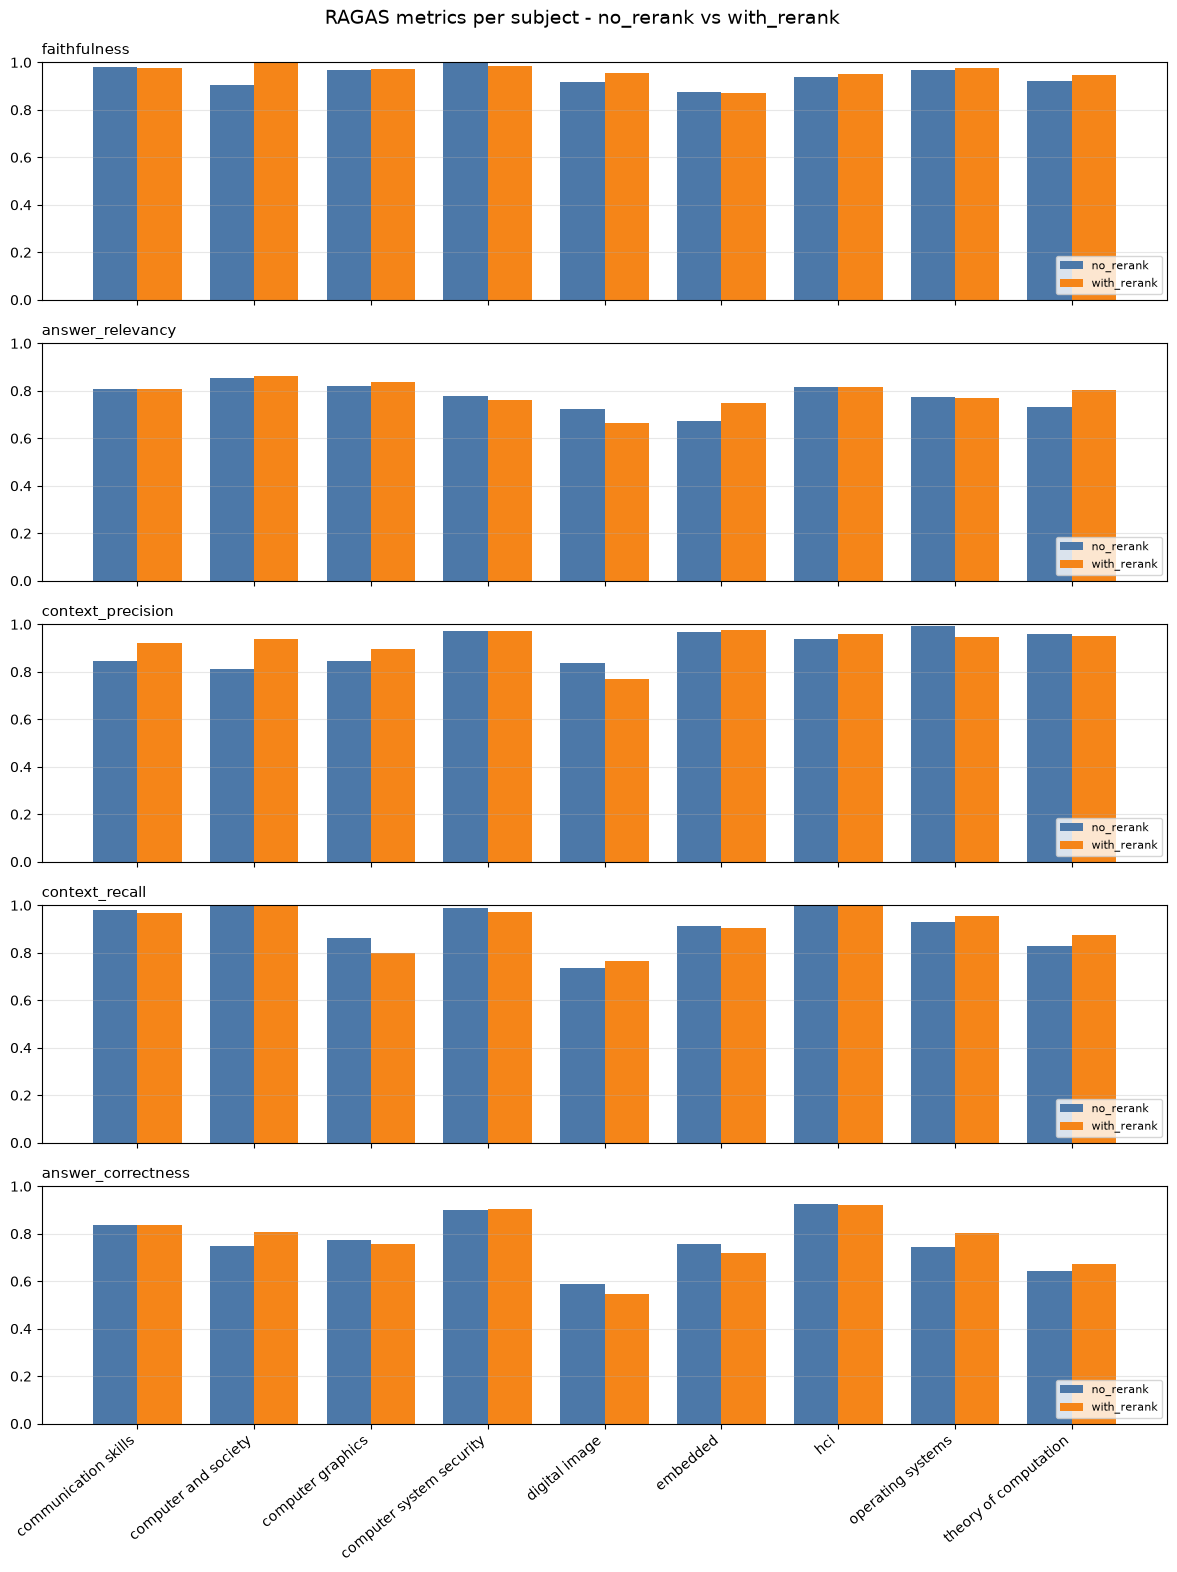

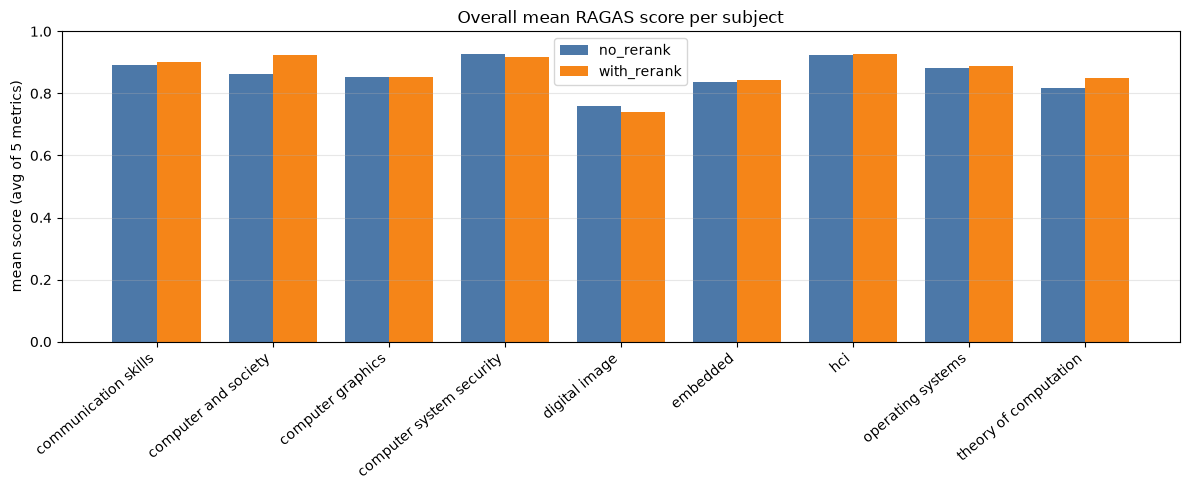

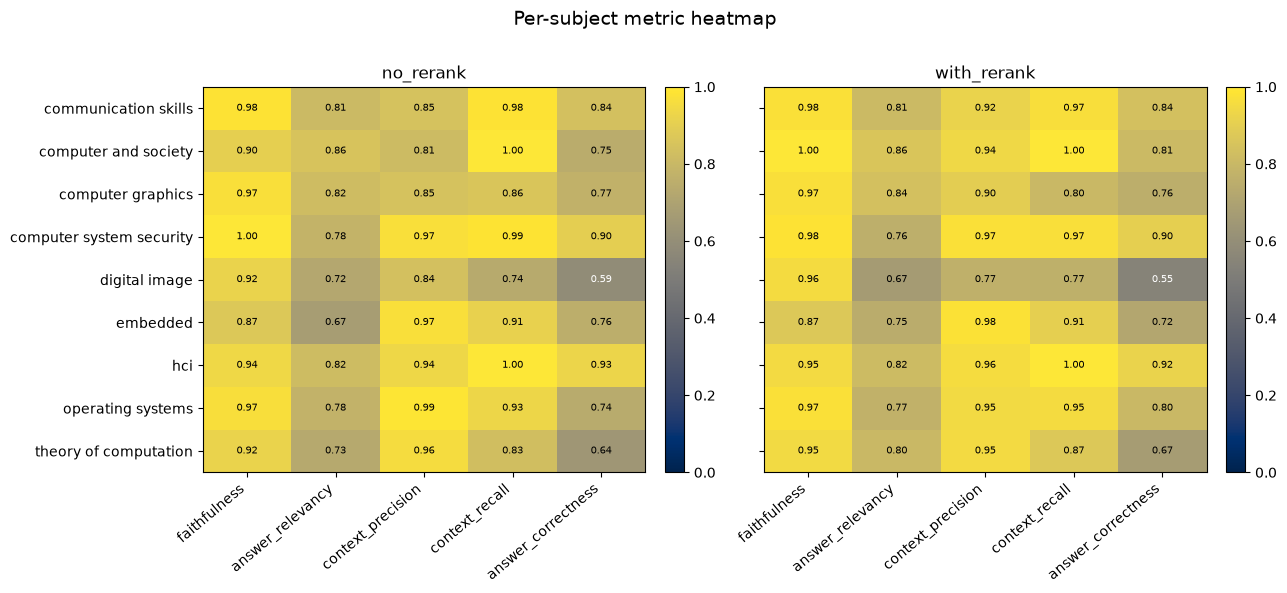

In [1]:
# ============================================================================
# Per-subject score diagrams  (no_rerank vs with_rerank)
# Reads the per-question RAGAS result CSVs and visualises the mean scores
# broken down by subject.
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

METRIC_COLS = ["faithfulness", "answer_relevancy", "context_precision",
               "context_recall", "answer_correctness"]


def _find_csv(name):
    """Locate a result CSV both inside the notebook (BASE_DIR) and standalone."""
    candidates = []
    if "BASE_DIR" in globals():
        candidates.append(Path(BASE_DIR) / name)
    candidates += [Path(name), Path("Evaluation") / name, Path.cwd() / name]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {name}; looked in {[str(c) for c in candidates]}")


pipelines = {
    "no_rerank":   _find_csv("ragas_results_no_rerank.csv"),
    "with_rerank": _find_csv("ragas_results_with_rerank.csv"),
}

# --- mean score per subject x metric, for each pipeline ----------------------
per_subject = {}
for pipe, path in pipelines.items():
    d = pd.read_csv(path)
    d["subject"] = d["subject"].astype(str).str.strip()
    cols = [c for c in METRIC_COLS if c in d.columns]
    per_subject[pipe] = d.groupby("subject")[cols].mean()

subjects = sorted(set().union(*[g.index for g in per_subject.values()]))

# overall score per subject = mean across the 5 metrics
overall = pd.DataFrame(
    {pipe: per_subject[pipe].mean(axis=1) for pipe in pipelines}
).reindex(subjects)
overall["delta (with - no)"] = overall["with_rerank"] - overall["no_rerank"]

print("=== Mean score per subject (averaged across 5 metrics) ===")
print(overall.round(4))
for pipe in pipelines:
    print(f"\n=== {pipe}: mean per subject x metric ===")
    print(per_subject[pipe].reindex(subjects).round(3))

# --- shared plotting setup ---------------------------------------------------
x = np.arange(len(subjects))
w = 0.38
colors = {"no_rerank": "#4C78A8", "with_rerank": "#F58518"}

# 1) one grouped-bar subplot per metric (subject on x, two pipelines) ---------
fig, axes = plt.subplots(len(METRIC_COLS), 1,
                         figsize=(12, 3.2 * len(METRIC_COLS)), sharex=True)
for ax, metric in zip(axes, METRIC_COLS):
    for i, pipe in enumerate(pipelines):
        vals = per_subject[pipe].reindex(subjects)[metric].values
        ax.bar(x + (i - 0.5) * w, vals, w, label=pipe, color=colors[pipe])
    ax.set_title(metric, fontsize=11, loc="left")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(subjects, rotation=40, ha="right")
fig.suptitle("RAGAS metrics per subject - no_rerank vs with_rerank", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

# 2) overall mean score per subject -------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
for i, pipe in enumerate(pipelines):
    ax.bar(x + (i - 0.5) * w, overall[pipe].values, w,
           label=pipe, color=colors[pipe])
ax.set_xticks(x)
ax.set_xticklabels(subjects, rotation=40, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("mean score (avg of 5 metrics)")
ax.set_title("Overall mean RAGAS score per subject")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# 3) per-subject metric heatmap, one panel per pipeline -----------------------
# Print-friendly palette: "cividis" is perceptually uniform, colour-blind safe
# and stays legible when printed in grayscale (unlike the washed-out low end of
# YlGn). Annotation text colour is chosen per cell from the cell's luminance so
# the numbers stay readable on both the dark (low) and light (high) ends.
HEATMAP_CMAP = "cividis"
cmap = plt.get_cmap(HEATMAP_CMAP)


def _text_color(value):
    r, g, b, _ = cmap(value)             # value is already in 0..1 (= norm)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.55 else "white"


fig, axes = plt.subplots(1, len(pipelines),
                         figsize=(6.5 * len(pipelines), 6), sharey=True)
for ax, pipe in zip(np.atleast_1d(axes), pipelines):
    g = per_subject[pipe].reindex(subjects)[METRIC_COLS]
    im = ax.imshow(g.values, vmin=0, vmax=1, cmap=HEATMAP_CMAP, aspect="auto")
    ax.set_xticks(range(len(METRIC_COLS)))
    ax.set_xticklabels(METRIC_COLS, rotation=40, ha="right")
    ax.set_yticks(range(len(subjects)))
    ax.set_yticklabels(subjects)
    ax.set_title(pipe)
    for r in range(len(subjects)):
        for c in range(len(METRIC_COLS)):
            val = g.values[r, c]
            ax.text(c, r, f"{val:.2f}",
                    ha="center", va="center", fontsize=7,
                    color=_text_color(val))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Per-subject metric heatmap", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
